## Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

In [36]:
files = []
def ourpath(path):
    for name in os.listdir(path):
        newpath = path+'\\'+name
        if os.path.isfile(newpath):
            if newpath.endswith(".csv"):
                if newpath.endswith("output.csv"):
                    continue
                if newpath.endswith("test.csv"):
                    continue
                files.append(newpath)
        else:
            ourpath(newpath)
    
ourpath(os.getcwd())

In [37]:
headers = ["image",
"logical",
"corrColor",
"corrR",
"corrG",
"corrB",
"image_path",
"oldColor",
"thisN",
"slider.response",
"slider.history",
"trials.thisIndex",
"filterCount.routineEndVal",
"trial_counter.routineEndVal",
"trial_1.started",
"trial_1.stopped",
"filterChange.routineEndVal",
"answer.routineEndVal",
"confidence.started",
"confidence.stopped",
"trials.mouse_2.x",
"trials.mouse_2.y",
"trials.mouse_2.time",
"confirm.started",
"wrongAnswer.started",
"correctAnswer.started",
"confirm.stopped",
"congrats.started",
"colorList.expEndVal",
"participant",
"session",
"date",
"expName",
"frameRate",
"expStart"
]

In [38]:
master_data = pd.DataFrame(columns = headers)
master_data

,image,logical,corrColor,corrR,corrG,corrB,image_path,oldColor,thisN,slider.response,...,correctAnswer.started,confirm.stopped,congrats.started,colorList.expEndVal,participant,session,date,expName,frameRate,expStart


In [ ]:
for elm in files:
    df_temp = pd.read_csv(elm,sep=",",engine="python")

    temp_data = pd.concat([master_data, df_temp])
    master_data = temp_data[temp_data.columns.intersection(headers)]
master_data = master_data.reset_index()

In [40]:
print(master_data.expName)

0            Tester2
1            Tester2
2            Tester2
3            Tester2
4            Tester2
            ...     
1269    Train3Laptop
1270    Train3Laptop
1271    Train3Laptop
1272    Train3Laptop
1273             NaN
Name: expName, Length: 1274, dtype: object


In [41]:
master_data.expName.unique()

array(['Tester2', nan, 'Baseline', 'TestStep1', 'Train1Laptop', 'Train1',
       'Train2', 'ExpDemo2', 'TestStep2', 'Train2Laptop', 'TestStep21',
       'ExpDemo3', 'Test3Laptop', 'Train3Laptop'], dtype=object)

In [42]:
master_data.loc[master_data.expName == "Train2", "expName"] = "Week1Train"
master_data.loc[master_data.expName == "Train1Laptop", "expName"] = "Week1Train"
master_data.loc[master_data.expName == "Train1", "expName"] = "Week1Train"
master_data.loc[master_data.expName == "Tester2", "expName"] = "Week1Demo"
master_data.loc[master_data.expName == "TestStep1", "expName"] = "Week1Test"

master_data.loc[master_data.expName == "Train2Laptop", "expName"] = "Week2Train"
master_data.loc[master_data.expName == "ExpDemo2", "expName"] = "Week2Demo"
master_data.loc[master_data.expName == "TestStep2", "expName"] = "Week2Test"

master_data.loc[master_data.expName == "TestStep21", "expName"] = "Week3Test"

master_data.loc[master_data.expName == "Train3Laptop", "expName"] = "Week4Train"
master_data.loc[master_data.expName == "ExpDemo3", "expName"] = "Week4Demo"
master_data.loc[master_data.expName == "Test3Laptop", "expName"] = "Week4Test"
master_data.expName.unique()

array(['Week1Demo', nan, 'Baseline', 'Week1Test', 'Week1Train',
       'Week2Demo', 'Week2Test', 'Week2Train', 'Week3Test', 'Week4Demo',
       'Week4Test', 'Week4Train'], dtype=object)

In [43]:
master_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   index                        1274 non-null   int64  
 1   image                        1154 non-null   object 
 2   logical                      1154 non-null   object 
 3   corrColor                    1154 non-null   object 
 4   corrR                        1154 non-null   float64
 5   corrG                        1154 non-null   float64
 6   corrB                        1154 non-null   float64
 7   image_path                   1154 non-null   object 
 8   oldColor                     82 non-null     object 
 9   thisN                        1154 non-null   float64
 10  slider.response              1093 non-null   float64
 11  slider.history               1154 non-null   object 
 12  trials.thisIndex             1154 non-null   float64
 13  filterCount.routin

In [44]:
master_data["filterCount.routineEndVal"]

0                                                     NaN
1       [115.63641429995187, 117.66781520005316, 118.9...
2                                                      []
3       [5.527772800065577, 7.528163800016046, 14.7557...
4       [8.93008409999311, 11.810803999891505, 13.3962...
                              ...                        
1269              [0.8898927999980515, 2.150628000003053]
1270              [2.135444899991853, 3.0551320999948075]
1271             [1.2967877000046428, 2.7611097000044538]
1272                                                  NaN
1273                                                  NaN
Name: filterCount.routineEndVal, Length: 1274, dtype: object

In [45]:
master_data["total_time"] = master_data["confirm.stopped"] - master_data["trial_1.started"]
master_data["trial_time"] = master_data["trial_1.stopped"] - master_data["trial_1.started"]
master_data["confidence_time"] = master_data["confidence.stopped"] - master_data["confidence.started"]
master_data["confirm_time"] = master_data["confirm.stopped"] - master_data["confirm.started"]


In [46]:
def point_count(row):
    if pd.notna(row["image"]):
        if pd.notna(row["wrongAnswer.started"]): return 0 - row["slider.response"]
        else: return row["slider.response"] - 0
master_data["points"] = master_data.apply(point_count, axis=1)

In [47]:
def filtercounter(row):
    if pd.notna(row["filterCount.routineEndVal"]):
        if len(row["filterCount.routineEndVal"]) > 2:
            #count commas
            if row["filterCount.routineEndVal"].count(",") == 0:
            # if no commas, 1
                return 1
            else: return row["filterCount.routineEndVal"].count(",")
        else: return 0
master_data["filterCounter"] = master_data.apply(filtercounter, axis=1)


In [48]:
def sessiontype(row):
    if pd.notna(row["image"]):
        if str(row["expName"]).endswith("Demo"):
            return 1
        elif str(row["expName"]).endswith("Test"):
            return 3
        elif str(row["expName"]).endswith("Test"):
            return 3
        else: return 2
    else: return None
master_data["sessionType"] = master_data.apply(sessiontype, axis=1)


In [49]:
master_data.loc[master_data.sessionType == 1, "session"] = 0

master_data.loc[master_data.session == "008-t", "session"] = 8.0
master_data.loc[master_data.session == "004-t", "session"] = 4.0
master_data.session.astype(float)
master_data.session.unique()

array([0.0, nan, 1.0, 2.0, 4.0, 3.0, 8.0, 5.0, 6.0, 7.0], dtype=object)

In [50]:
def colordif(row):
    if pd.notna(row["image"]):
        if row["corrColor"] == "Red" | row["corrColor"] == "Green" | row["corrColor"] == "Blue":
            return 1
        if row["corrColor"] == "Cyan" | row["corrColor"] == "Yellow" | row["corrColor"] == "Grey" | row["corrColor"] == "Bordeaux" | row["corrColor"] == "Brown" | row["corrColor"] == "Teal":
            return 2
        if row["corrColor"] == "Purple":
            return 3
        if row["corrColor"] == "Pink" | row["corrColor"] == "Seafoam" | row["corrColor"] == "Orange" | row["corrColor"] == "Lime-green":
            return 4
    else: return None
master_data["colorDifficulty"] = master_data.apply(sessiontype, axis=1)


In [51]:
master_data[:500:10]

,index,image,logical,corrColor,corrR,corrG,corrB,image_path,oldColor,thisN,...,frameRate,expStart,total_time,trial_time,confidence_time,confirm_time,points,filterCounter,sessionType,colorDifficulty
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.202666,2026-03-16 19h15.41.289469 +0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,1,016_Green.jpg,True,Green,9.0,100.0,4.0,01-1/016_Green_0.png,NaN,0.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,36.949900,31.152573,3.664915,1.380771,5.0,2.0,2.0,2.0
20,11,016_Yellow.jpg,True,Yellow,98.0,100.0,11.0,01-1/016_Yellow_0.png,NaN,10.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,29.089668,24.074720,2.856970,1.443941,5.0,6.0,2.0,2.0
30,21,025_Cyan.jpg,True,Cyan,7.0,100.0,99.0,01-1/025_Cyan_0.png,NaN,20.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,12.722990,8.539972,2.725392,0.749464,5.0,0.0,2.0,2.0
40,31,016_Cyan.jpg,True,Cyan,0.0,100.0,96.0,01-1/016_Cyan_0.png,NaN,30.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,21.335952,16.762993,2.608537,1.239144,5.0,0.0,2.0,2.0
50,41,025_Green.jpg,True,Green,0.0,100.0,5.0,01-1/025_Green_0.png,NaN,40.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,15.694912,6.388306,2.977308,5.607395,5.0,0.0,2.0,2.0
60,51,027_Green.jpg,True,Green,1.0,88.0,0.0,01-1/027_Green_0.png,NaN,50.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,10.461091,5.599604,3.356738,0.778186,5.0,0.0,2.0,2.0
70,61,014_Yellow.jpg,True,Yellow,100.0,98.0,11.0,01-1/014_Yellow_0.png,NaN,60.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,17.598044,11.971089,3.828174,1.081939,5.0,0.0,2.0,2.0
80,71,017_Red.jpg,True,Red,100.0,4.0,7.0,01-1/017_Red_0.png,NaN,70.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,7.578126,3.769890,2.448412,0.645525,5.0,0.0,2.0,2.0
90,5,DemoYellow.jpg,True,Yellow,96.0,100.0,0.0,Demo/DemoYellow_0.png,NaN,4.0,...,60.097129,2026-03-13 17h12.53.150256 +0100,49.039197,41.090796,5.630516,1.589372,5.0,3.0,1.0,1.0


In [52]:
drops = master_data[pd.isna(master_data["slider.response"]) & pd.notna(master_data["image"])].index
print(drops, len(drops))
display(master_data.iloc[drops])
master_data = master_data.drop(drops)

Index([ 82, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
       133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 321, 419, 420, 421, 422, 423,
       424, 559, 560, 561, 562, 563, 564, 686, 687, 688, 689, 690, 691, 813,
       814, 815, 816, 817, 818],
      dtype='int64') 61


,index,image,logical,corrColor,corrR,corrG,corrB,image_path,oldColor,thisN,...,frameRate,expStart,total_time,trial_time,confidence_time,confirm_time,points,filterCounter,sessionType,colorDifficulty
82,73,012_Green.jpg,True,Green,3.0,94.0,4.0,01-1/012_Green_0.png,NaN,72.0,...,59.491514,2026-03-16 19h25.47.500195 +0100,0.007758,0.000057,0.000279,0.000063,NaN,0.0,2.0,2.0
120,26,029_Cyan.jpg,True,Cyan,2.0,100.0,88.0,01-1/029_Cyan_0.png,NaN,25.0,...,60.105329,2026-03-19 14h54.40.977751 +0100,0.024673,0.000133,0.000837,0.000134,NaN,0.0,2.0,2.0
121,27,006_Purple.jpg,True,Purple,65.0,0.0,100.0,01-1/006_Purple_0.png,NaN,26.0,...,60.105329,2026-03-19 14h54.40.977751 +0100,0.031731,0.000125,0.000821,0.000127,NaN,0.0,2.0,2.0
122,28,022_Red.jpg,True,Red,100.0,0.0,1.0,01-1/022_Red_0.png,NaN,27.0,...,60.105329,2026-03-19 14h54.40.977751 +0100,0.028674,0.000140,0.000826,0.000132,NaN,0.0,2.0,2.0
123,29,010_Red.jpg,True,Red,99.0,0.0,12.0,01-1/010_Red_0.png,NaN,28.0,...,60.105329,2026-03-19 14h54.40.977751 +0100,0.032564,0.000126,0.000826,0.000135,NaN,0.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,27,009_Yellow.jpg,False,Yellow,100.0,97.0,2.0,02-t/009_Yellow_0.png,Cyan,26.0,...,59.871456,2026-04-08 16h35.59.575052 +0200,0.009766,0.000061,0.000268,0.000058,NaN,0.0,3.0,3.0
815,28,022_Blue.jpg,False,Blue,1.0,8.0,96.0,02-t/022_Blue_0.png,Green,27.0,...,59.871456,2026-04-08 16h35.59.575052 +0200,0.011778,0.000058,0.000351,0.000057,NaN,0.0,3.0,3.0
816,29,023_Yellow.jpg,True,Yellow,100.0,86.0,0.0,01-1/023_Yellow_0.png,NaN,28.0,...,59.871456,2026-04-08 16h35.59.575052 +0200,0.009879,0.000065,0.000290,0.000054,NaN,0.0,3.0,3.0
817,30,014_Orange.jpg,True,Orange,100.0,61.0,7.0,02-1/014_Orange_0.png,NaN,29.0,...,59.871456,2026-04-08 16h35.59.575052 +0200,0.012498,0.000058,0.000289,0.000057,NaN,0.0,3.0,3.0


In [54]:
master_data.trial_time.quantile([0.00,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.98,0.99,1])


0.00       3.668991
0.10       5.803532
0.20       7.274312
0.30       8.658029
0.40       9.922768
0.50      11.401562
0.60      13.196287
0.70      15.457997
0.80      19.023258
0.90      27.331516
0.98      52.897327
0.99      83.391984
1.00    1155.961154
Name: trial_time, dtype: float64

In [56]:
dropped = master_data[master_data["trial_time"].notna() & (master_data["trial_time"] > 200)]
master_data = master_data[master_data["trial_time"].notna() & (master_data["trial_time"] < 200)]

In [57]:
display(dropped)

,index,image,logical,corrColor,corrR,corrG,corrB,image_path,oldColor,thisN,...,frameRate,expStart,total_time,trial_time,confidence_time,confirm_time,points,filterCounter,sessionType,colorDifficulty
263,22,009_Green.jpg,True,Green,2.0,100.0,5.0,01-1/009_Green_0.png,NaN,21.0,...,59.950780,2026-03-24 22h09.03.889778 +0100,1188.873636,1155.961154,17.789518,14.406460,-1.0,1.0,2.0,2.0
482,24,009_Cyan.jpg,True,Cyan,3.0,100.0,95.0,01-1/009_Cyan_0.png,NaN,23.0,...,60.104606,2026-03-31 11h43.03.387357 +0200,317.116169,312.401252,3.007974,0.987258,4.0,9.0,2.0,2.0
483,25,006_Purple.jpg,True,Purple,65.0,0.0,100.0,01-1/006_Purple_0.png,NaN,24.0,...,60.104606,2026-03-31 11h43.03.387357 +0200,258.787987,254.694191,2.742278,0.623556,4.0,1.0,2.0,2.0


In [59]:
master_data.trial_time.quantile([0.00,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.98,0.99,1])


0.00      3.668991
0.10      5.802007
0.20      7.260317
0.30      8.648659
0.40      9.912326
0.50     11.390637
0.60     13.170320
0.70     15.428047
0.80     18.904562
0.90     27.133038
0.98     47.834439
0.99     67.576110
1.00    185.426278
Name: trial_time, dtype: float64

In [60]:
master_data = master_data.dropna(thresh=35, axis=0)

In [62]:
# Baseline = Week 0
master_data["week"] = np.where(master_data["expName"] == "Baseline", 0, np.nan)

# Extract week number from expName (e.g., Week2Demo → 2)
master_data["week"] = master_data["week"].fillna(master_data["expName"].str.extract(r"Week(\d+)")[0].astype(float))
# Sessions that belong to Week 3 inside Week2Train
week3_sessions = {"5", "6", "7", "8"}

mask = master_data["expName"] == "Week2Train"
master_data.loc[mask & master_data["session"].isin(week3_sessions), "week"] = 3
master_data.loc[master_data.expName == "Week1Demo", 'week'] = 0

master_data.loc[master_data.week < 2, "num_colours"] = 6
master_data.loc[master_data.week == 2, "num_colours"] = 10
master_data.loc[master_data.week == 3, "num_colours"] = 10
master_data.loc[master_data.week > 3, "num_colours"] = 14

In [63]:
master_data["accuracy"] = master_data["wrongAnswer.started"].isna().astype(int)
master_data["confidence_score"] = (master_data["slider.response"] - 1) / 4

week_stats = master_data.groupby("week")["trial_time"].agg(["mean", "std"]) #Speed normalization (within each week)

master_data = master_data.merge(week_stats, on="week", how="left")

# z-time (faster = higher score)
master_data["z_time"] = (master_data["mean"] - master_data["trial_time"]) / master_data["std"] # Show as mu and sigma signs
master_data["speed_score"] = 1 / (1 + np.exp(-master_data["z_time"]))


In [64]:
difficulty_map = {6: 1.0, 10: 1.2, 14: 1.4}
master_data["difficulty_weight"] = master_data["num_colours"].map(difficulty_map)

In [65]:
master_data["score"] = master_data["difficulty_weight"] * (master_data["accuracy"] + 0.3 * master_data["speed_score"] + 0.2 * master_data["confidence_score"]) # difficulty weight is either 1, 1.2 or 1.4
master_data["base_score"] = master_data["accuracy"] + 0.2 * master_data["confidence_score"]


In [66]:
sortedmaster = master_data.sort_values(by=["participant", "week", "session", "index"]).reset_index(drop=True)
sortedmaster["trial_continuous"] = sortedmaster.groupby("participant").cumcount() + 1

In [67]:
ideal_df = pd.read_excel("ColourComparisonMatrix.xlsx", sheet_name="Sheet1")
sortedmaster = sortedmaster.merge(
    ideal_df[["colour", "R", "G", "B"]],
    left_on="corrColor",
    right_on="colour",
    how="left",
    suffixes=("", "_ideal")
)
sortedmaster["rgb_distance"] = (
    (sortedmaster["corrR"] - sortedmaster["R"]).abs() +
    (sortedmaster["corrG"] - sortedmaster["G"]).abs() +
    (sortedmaster["corrB"] - sortedmaster["B"]).abs()
)


In [88]:
ratio_cat_map1 = {"Red": 100,"Green": 100,"Blue": 100, "Yellow": 100,"Cyan": 100,"Pink": 100,
                 "Purple": 100,"Orange": 100,"Lime-green": 100,"Seafoam": 100,"Grey": 100,
                 "Brown": 50,"Bordeaux": 50,"Teal": 50,}
sortedmaster["ratio_cat1"] = sortedmaster["corrColor"].map(ratio_cat_map1)
ratio_cat_map2 = {"Red": 0,"Green": 0,"Blue": 0, "Yellow": 100,"Cyan": 100,"Pink": 40,
                 "Purple": 60,"Orange": 60,"Lime-green": 60,"Seafoam": 60,"Grey": 100,
                 "Brown": 30,"Bordeaux": 20,"Teal": 50,}
sortedmaster["ratio_cat2"] = sortedmaster["corrColor"].map(ratio_cat_map2)

ratio_cat_map3 = {"Red": "100:0:0","Green": "100:0:0","Blue": "100:0:0", "Yellow": "100:100:0","Cyan": "100:100:0","Pink": "100:40:0",
                 "Purple": "100:60:0","Orange": "100:60:0","Lime-green": "100:60:0","Seafoam": "100:60:0","Grey": "50:50:50",
                 "Brown": "50:30:0","Bordeaux": "50:20:0","Teal": "50:20:0",}
sortedmaster["ratio_cat3"] = sortedmaster["corrColor"].map(ratio_cat_map3)

In [69]:
sortedmaster = sortedmaster.drop(columns=["colour","R","G","B"])

In [70]:
sortedmaster["session_continuous"] = (
    sortedmaster.groupby("participant")["session"]
    .transform(lambda s: s.ne(s.shift()).cumsum())
)

In [ ]:
sortedmaster.to_csv("1output.csv", sep = ",", encoding="utf-8")

# Graphs start

In [ ]:
new_style = {
'grid.color': '#FFF0D1',
'axes.facecolor': '#FFF0D1',
'grid.linestyle': '--',
}

In [ ]:
session_df1 = (
    sortedmaster.groupby(["participant", "week", "session"])
    .agg(
        performance=("score", "mean"),
        mean_basescore=("base_score", "mean"),
        accuracy_rate=("accuracy", "mean"),
        mean_time=("trial_time", "mean"),
        mean_confidence=("slider.response", "mean"),
        n_trials=("score", "size"),
        test_images=("oldColor","size"),
        mean_image_change=("filterCounter","mean"),
        mean_confirm_time=("confirm_time", "mean")
    )
    .reset_index()
)

session_df1 = session_df1.sort_values(["participant", "week", "session"])

session_df1["session_order"] = (
    session_df1.groupby("participant").cumcount() + 1
)
session_df1["speed"] = 1 / session_df1["mean_time"]

In [ ]:
session_df1

,participant,week,session,performance,mean_basescore,accuracy_rate,mean_time,mean_confidence,n_trials,test_images,mean_image_change,mean_confirm_time,session_order,speed
0,1.0,0.0,0.0,1.297850,1.200000,1.000000,49.505386,5.000000,6,6,4.000000,4.076899,1,0.020200
1,1.0,0.0,1.0,1.343484,1.175000,0.986111,13.879025,4.777778,72,72,0.430556,1.772453,2,0.072051
2,1.0,1.0,1.0,1.354715,1.198000,1.000000,11.048985,4.960000,25,25,1.200000,0.993742,3,0.090506
3,1.0,1.0,2.0,1.389381,1.200000,1.000000,5.481958,5.000000,25,25,1.120000,0.759225,4,0.182417
4,1.0,1.0,3.0,1.363930,1.195833,1.000000,9.035593,4.916667,24,24,1.500000,0.796819,5,0.110673
5,1.0,1.0,4.0,1.324311,1.154000,0.960000,8.590561,4.880000,25,25,1.040000,1.042573,6,0.116407
6,1.0,2.0,0.0,1.501395,1.160000,1.000000,51.666958,4.200000,10,10,0.800000,0.719540,7,0.019355
7,1.0,2.0,1.0,1.286002,0.923214,0.750000,16.959484,4.464286,28,28,1.500000,2.780711,8,0.058964
8,1.0,2.0,2.0,1.210393,0.898077,0.730769,30.114609,4.346154,26,26,3.384615,3.503205,9,0.033206
9,1.0,2.0,3.0,1.510600,1.105357,0.928571,15.919643,4.535714,28,28,2.285714,1.131967,10,0.062815


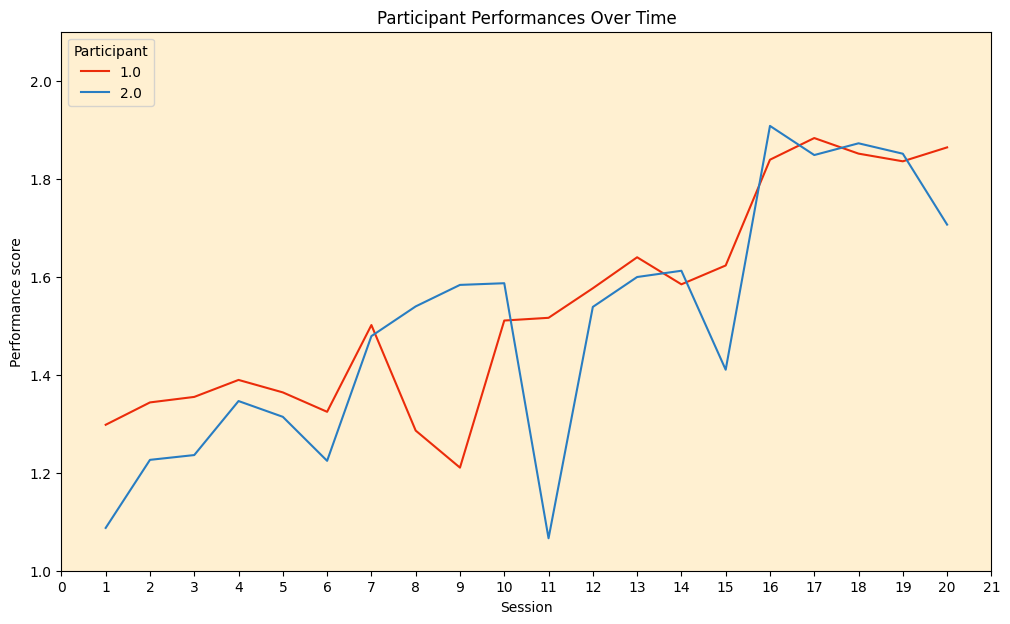

In [ ]:
custom_palette1 = sns.color_palette(["#EB2C0A", "#287DC2"])
with sns.axes_style(new_style):
    plt.figure(figsize=(12, 7))
    ax = sns.lineplot(
        data=session_df1,
        x="session_order",              
        y="performance",       
        hue="participant",
        palette = custom_palette1,
        estimator=None          
    )
    ax.set(xlim=(0,17),ylim=(1,2.1))
    ax.set_xticks(range(0,22,1))
    ax.legend(title="Participant",)
    ax.set_title("Participant Performances Over Time")
    ax.set_xlabel("Session")
    ax.set_ylabel("Performance score")
    sns.move_legend(ax, "upper left")
    plt.show()

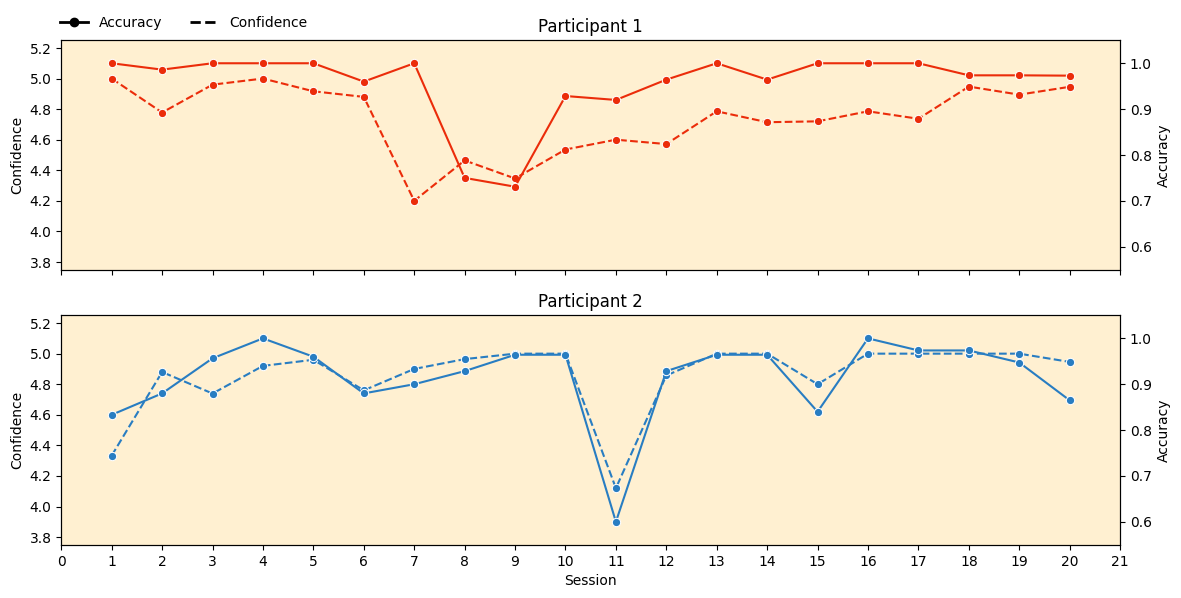

In [ ]:
custom_palette1 = ["#EB2C0A", "#287DC2"]

participants = session_df1["participant"].unique()

with sns.axes_style(new_style):
    fig, axes = plt.subplots(len(participants), 1, figsize=(12, 6), sharex=True)

    if len(participants) == 1:
        axes = [axes]

    for i, p in enumerate(participants):
        ax1 = axes[i]
        ax2 = ax1.twinx()

        df_p = session_df1[session_df1["participant"] == p]

        # Confidence (dashed)
        sns.lineplot(
            data=df_p,
            x="session_order",
            y="mean_confidence",
            color=custom_palette1[i],
            marker="o",
            linestyle="--",
            ax=ax1
        )

        # Accuracy (solid)
        sns.lineplot(
            data=df_p,
            x="session_order",
            y="accuracy_rate",
            color=custom_palette1[i],
            marker="o",
            linestyle="-",
            ax=ax2
        )

        # Axis formatting
        ax1.set_xlim(0, 17)
        ax1.set_ylim(3.75, 5.25)
        ax2.set_ylim(0.55, 1.05)

        ax1.set_ylabel(f"Confidence")
        ax2.set_ylabel("Accuracy")

        ax1.set_title(f"Participant {int(p)}")

    axes[-1].set_xlabel("Session")
    axes[-1].set_xticks(range(0, 22, 1))
    
    legend_elements = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", marker="o", label="Accuracy"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="Confidence"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.051, 1),
        ncol=2,
        frameon=False
    )
    plt.grid(False)
    plt.tight_layout()
    plt.show()

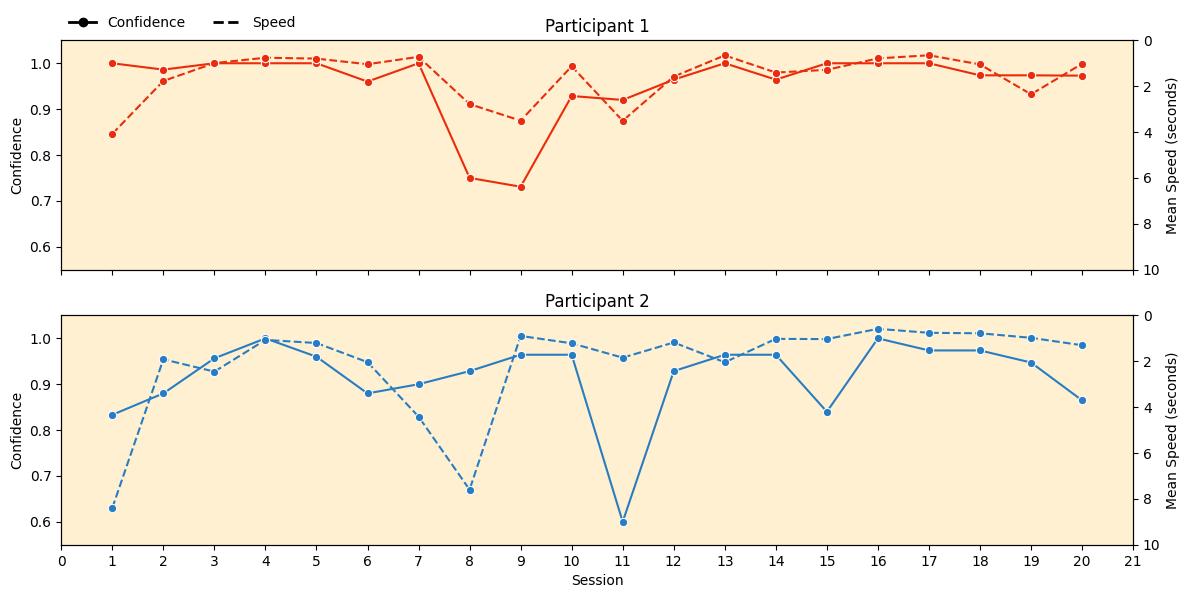

In [ ]:
custom_palette1 = ["#EB2C0A", "#287DC2"]

participants = session_df1["participant"].unique()

with sns.axes_style(new_style):
    fig, axes = plt.subplots(len(participants), 1, figsize=(12, 6), sharex=True)

    if len(participants) == 1:
        axes = [axes]

    for i, p in enumerate(participants):
        ax1 = axes[i]
        ax2 = ax1.twinx()

        df_p5 = session_df1[session_df1["participant"] == p]

        # Accuracy (solid)
        sns.lineplot(
            data=df_p5,
            x="session_order",
            y="accuracy_rate",
            color=custom_palette1[i],
            marker="o",
            linestyle="-",
            ax=ax1
        )

        # confirm_time (dashed)
        sns.lineplot(
            data=df_p5,
            x="session_order",
            y="mean_confirm_time",
            color=custom_palette1[i],
            marker="o",
            linestyle="--",
            ax=ax2
        )

        # Axis formatting
        ax1.set_xlim(0, 17)
        ax1.set_ylim(0.55, 1.05)
        ax2.set_ylim(10, 0)

        ax1.set_ylabel(f"Confidence")
        ax2.set_ylabel("Mean Speed (seconds)")

        ax1.set_title(f"Participant {int(p)}")
        plt.grid(False)

    axes[-1].set_xlabel("Session")
    axes[-1].set_xticks(range(0, 22, 1))

    legend_elements = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", marker="o", label="Confidence"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="Speed"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.051, 1),
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

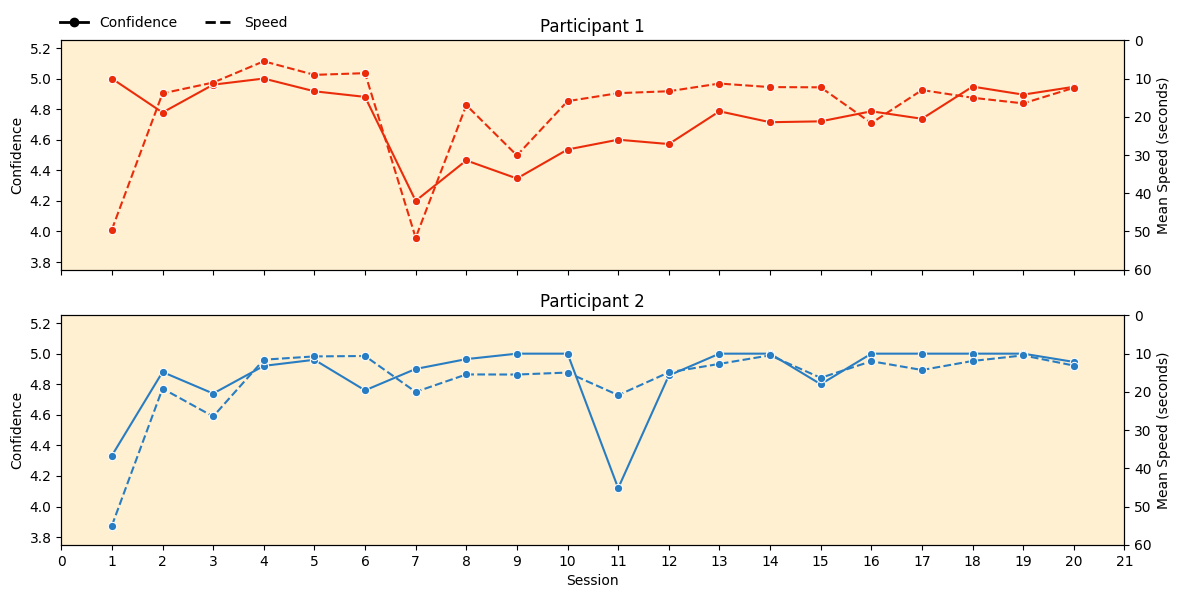

In [ ]:
custom_palette1 = ["#EB2C0A", "#287DC2"]

participants = session_df1["participant"].unique()

with sns.axes_style(new_style):
    fig, axes = plt.subplots(len(participants), 1, figsize=(12, 6), sharex=True)

    if len(participants) == 1:
        axes = [axes]

    for i, p in enumerate(participants):
        ax1 = axes[i]
        ax2 = ax1.twinx()

        df_p1 = session_df1[session_df1["participant"] == p]

        # Confidence (solid)
        sns.lineplot(
            data=df_p1,
            x="session_order",
            y="mean_confidence",
            color=custom_palette1[i],
            marker="o",
            linestyle="-",
            ax=ax1
        )

        # Mean speed (dashed)
        sns.lineplot(
            data=df_p1,
            x="session_order",
            y="mean_time",
            color=custom_palette1[i],
            marker="o",
            linestyle="--",
            ax=ax2
        )

        # Axis formatting
        ax1.set_xlim(0, 17)
        ax1.set_ylim(3.75, 5.25)
        ax2.set_ylim(60, 0)

        ax1.set_ylabel(f"Confidence")
        ax2.set_ylabel("Mean Speed (seconds)")

        ax1.set_title(f"Participant {int(p)}")
        plt.grid(False)

    axes[-1].set_xlabel("Session")
    axes[-1].set_xticks(range(0, 22, 1))

    legend_elements = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", marker="o", label="Confidence"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="Speed"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.051, 1),
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

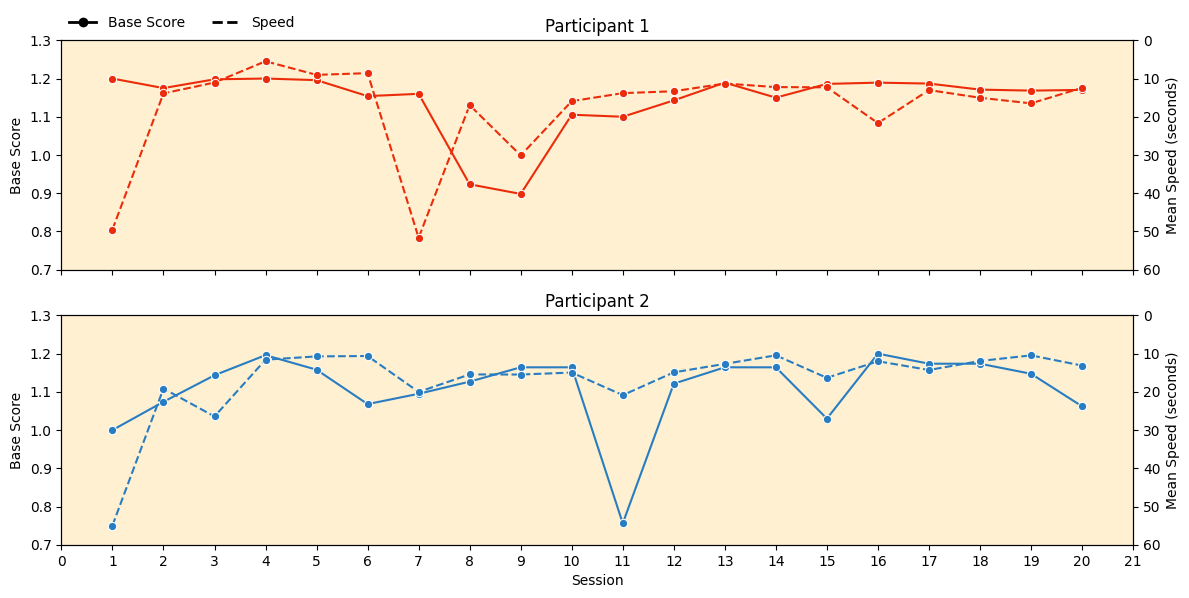

In [ ]:
custom_palette1 = ["#EB2C0A", "#287DC2"]

participants = session_df1["participant"].unique()

with sns.axes_style(new_style):
    fig, axes = plt.subplots(len(participants), 1, figsize=(12, 6), sharex=True)

    if len(participants) == 1:
        axes = [axes]

    for i, p in enumerate(participants):
        ax1 = axes[i]
        ax2 = ax1.twinx()

        df_p2 = session_df1[session_df1["participant"] == p]

        # Base_score (solid)
        sns.lineplot(
            data=df_p2,
            x="session_order",
            y="mean_basescore",
            color=custom_palette1[i],
            marker="o",
            linestyle="-",
            ax=ax1
        )

        # Mean time (dashed)
        sns.lineplot(
            data=df_p2,
            x="session_order",
            y="mean_time",
            color=custom_palette1[i],
            marker="o",
            linestyle="--",
            ax=ax2
        )

        # Axis formatting
        ax1.set_xlim(0, 17)
        ax1.set_ylim(0.7, 1.3)
        ax2.set_ylim(60, 0)

        ax1.set_ylabel(f"Base Score")
        ax2.set_ylabel("Mean Speed (seconds)")

        ax1.set_title(f"Participant {int(p)}")
        plt.grid(False)

    axes[-1].set_xlabel("Session")
    axes[-1].set_xticks(range(0, 22, 1))

    legend_elements = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", marker="o", label="Base Score"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="Speed"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.051, 1),
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

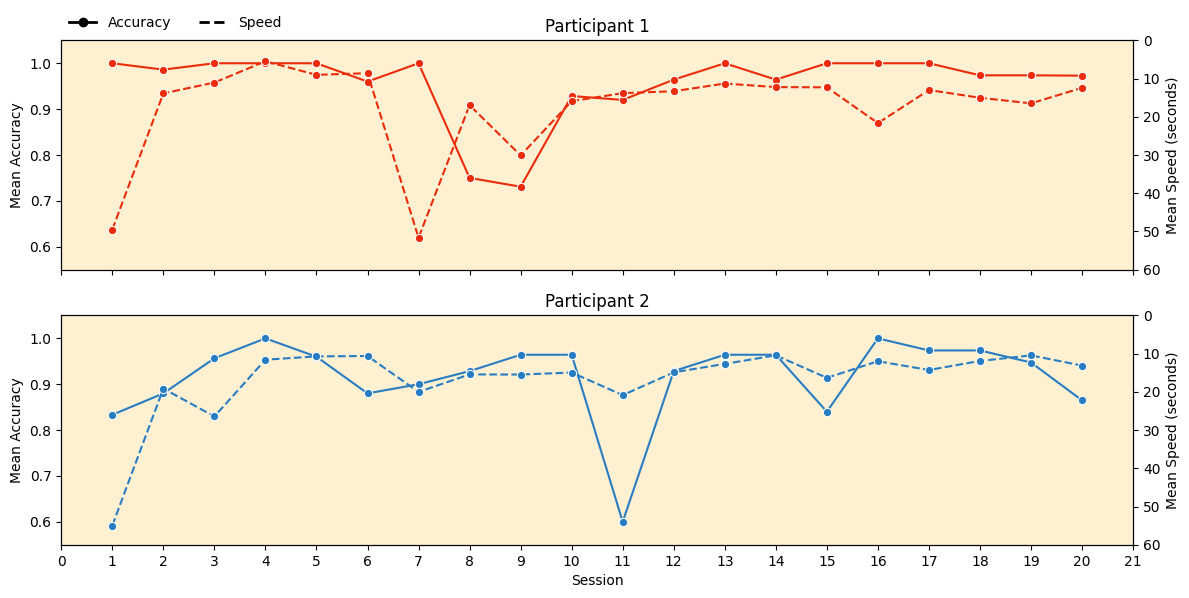

In [ ]:
custom_palette1 = ["#EB2C0A", "#287DC2"]

participants = session_df1["participant"].unique()

with sns.axes_style(new_style):
    fig, axes = plt.subplots(len(participants), 1, figsize=(12, 6), sharex=True)

    if len(participants) == 1:
        axes = [axes]

    for i, p in enumerate(participants):
        ax1 = axes[i]
        ax2 = ax1.twinx()

        df_p3 = session_df1[session_df1["participant"] == p]

        # Accuracy (solid)
        sns.lineplot(
            data=df_p3,
            x="session_order",
            y="accuracy_rate",
            color=custom_palette1[i],
            marker="o",
            linestyle="-",
            ax=ax1
        )

        # Mean time (dashed)
        sns.lineplot(
            data=df_p3,
            x="session_order",
            y="mean_time",
            color=custom_palette1[i],
            marker="o",
            linestyle="--",
            ax=ax2
        )

        # Axis formatting
        ax1.set_xlim(0, 17)
        ax2.set_ylim(60, 0)
        ax1.set_ylim(0.55, 1.05)

        ax1.set_ylabel(f"Mean Accuracy")
        ax2.set_ylabel("Mean Speed (seconds)")

        ax1.set_title(f"Participant {int(p)}")
        plt.grid(False)

    axes[-1].set_xlabel("Session")
    axes[-1].set_xticks(range(0, 22, 1))

    legend_elements = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", marker="o", label="Accuracy"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="Speed"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.051, 1),
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

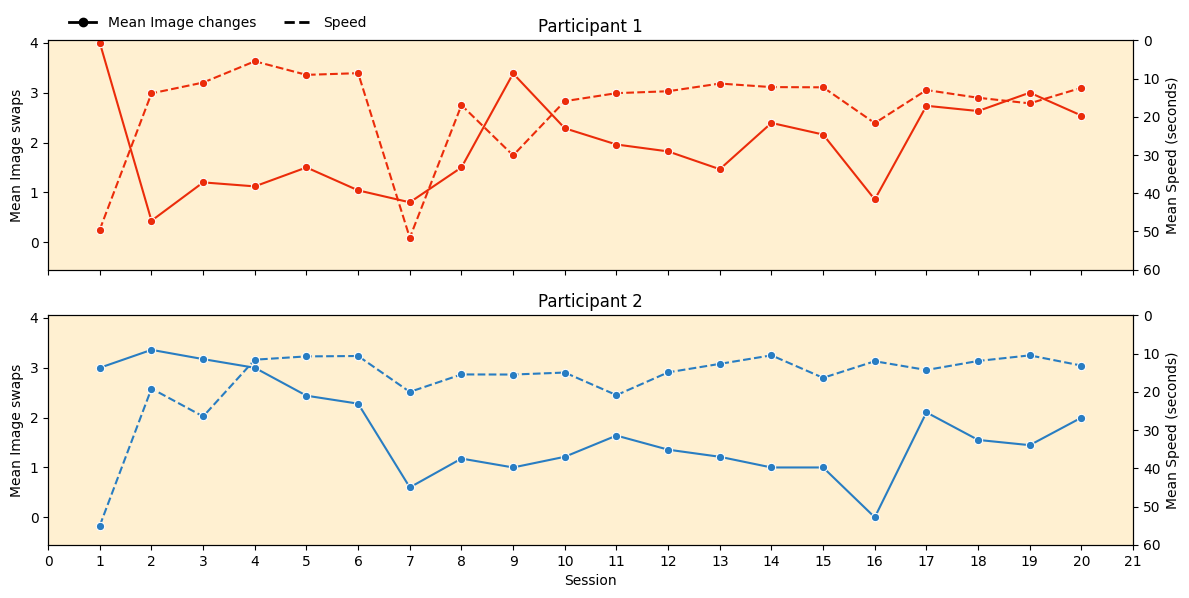

In [ ]:
custom_palette1 = ["#EB2C0A", "#287DC2"]

participants = sortedmaster["participant"].unique()

with sns.axes_style(new_style):
    fig, axes = plt.subplots(len(participants), 1, figsize=(12, 6), sharex=True)

    if len(participants) == 1:
        axes = [axes]

    for i, p in enumerate(participants):
        ax1 = axes[i]
        ax2 = ax1.twinx()

        df_p4 = session_df1[session_df1["participant"] == p]

        # img changes (solid)
        sns.lineplot(
            data=df_p4,
            x="session_order",
            y="mean_image_change",
            color=custom_palette1[i],
            marker="o",
            linestyle="-",
            ax=ax1,
            estimator=None
        )

        # Mean time (dashed)
        sns.lineplot(
            data=df_p4,
            x="session_order",
            y="mean_time",
            color=custom_palette1[i],
            marker="o",
            linestyle="--",
            ax=ax2,
            estimator=None
        )

        # Axis formatting
        ax1.set_xlim(0, 1)
        ax2.set_ylim(60, 0)
        ax1.set_ylim(-0.55, 4.05)

        ax1.set_ylabel(f"Mean Image swaps")
        ax2.set_ylabel("Mean Speed (seconds)")

        ax1.set_title(f"Participant {int(p)}")
        plt.grid(False)

    axes[-1].set_xlabel("Session")
    axes[-1].set_xticks(range(0, 22, 1))

    legend_elements = [
        Line2D([0], [0], color="black", lw=2, linestyle="-", marker="o", label="Mean Image changes"),
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="Speed"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.051, 1),
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

In [ ]:
color_order = [
    "Red",
    "Orange",
    "Brown",
    "Yellow",
    "Lime-green",
    "Green",
    "Seafoam",
    "Cyan",
    "Teal",
    "Blue",
    "Purple",
    "Pink",
    "Bordeaux",
    "Grey"
]

In [ ]:
wrong_only = master_data[master_data["wrongAnswer.started"].notna()]

color_order = [
    "Red",
    "Orange",
    "Brown",
    "Yellow",
    "Lime-green",
    "Green",
    "Seafoam",
    "Cyan",
    "Teal",
    "Blue",
    "Purple",
    "Pink",
    "Bordeaux",
    "Grey"
]

# Convert both columns to ordered categorical
wrong_only["corrColor"] = pd.Categorical(wrong_only["corrColor"], categories=color_order, ordered=True)
wrong_only["answer.routineEndVal"] = pd.Categorical(wrong_only["answer.routineEndVal"], categories=color_order, ordered=True)

cm = pd.crosstab(
    wrong_only["corrColor"],
    wrong_only["answer.routineEndVal"],
    rownames=["corrColor (true)"],
    colnames=["answer.final (predicted)"]
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap on Correct vs Wrong Guessed Colours")
plt.ylabel("True Colour")
plt.xlabel("Guessed Colour")
plt.tight_layout()
plt.show()

In [ ]:
color_df = (
    sortedmaster.groupby(["participant", "week", "corrColor", "session", "sessionType"])
    .agg(
        performance=("score", "mean"),
        accuracy_rate=("accuracy", "mean"),
        mean_time=("trial_time", "mean"),
        mean_confidence=("slider.response", "mean"),
    )
    .reset_index()
)
color_df.loc[
    (color_df["week"] == 4) & (color_df["session"] == 4),
    "week"
] = 5
color_df = color_df.sort_values(["participant", "week", "corrColor"])
color_df.drop(columns="session")
color_df.participant.astype(int)

0      1
1      1
2      1
3      1
4      1
      ..
351    2
356    2
365    2
370    2
375    2
Name: participant, Length: 380, dtype: int64

In [ ]:
color_df[:20]

,participant,week,corrColor,session,sessionType,performance,accuracy_rate,mean_time,mean_confidence
0,1.0,0.0,Blue,0.0,1.0,1.333366,1.000000,24.314254,5.000000
1,1.0,0.0,Blue,1.0,2.0,1.374574,1.000000,11.749628,5.000000
2,1.0,0.0,Cyan,0.0,1.0,1.319908,1.000000,28.451455,5.000000
3,1.0,0.0,Cyan,1.0,2.0,1.361607,1.000000,16.737624,5.000000
4,1.0,0.0,Green,0.0,1.0,1.331295,1.000000,24.943758,5.000000
5,1.0,0.0,Green,1.0,2.0,1.365554,1.000000,13.082546,4.909091
6,1.0,0.0,Purple,0.0,1.0,1.309325,1.000000,31.812142,5.000000
7,1.0,0.0,Purple,1.0,2.0,1.199941,0.909091,18.018180,3.727273
8,1.0,0.0,Red,0.0,1.0,1.200894,1.000000,149.975735,5.000000
9,1.0,0.0,Red,1.0,2.0,1.383499,1.000000,7.785418,4.923077


In [ ]:
# Get unique sessions in order
session_keys = sortedmaster[["week", "session"]].drop_duplicates()

# Assign continuous_session starting at 0
session_keys["continuous_session"] = range(len(session_keys))

# Merge back to all rows
sortedmaster = sortedmaster.merge(
    session_keys,
    on=["week", "session"],
    how="left"
)

In [ ]:
#sortedmaster = sortedmaster.drop(columns="continuous_session_x")

sortedmaster = sortedmaster.rename(columns={"continuous_session_y": "continuous_session"})


In [ ]:
sortedmaster.loc[sortedmaster["continuous_session"] == 20, "continuous_session"] = 1
sortedmaster["continuous_session"] += 1

In [ ]:
Answers = (
    sortedmaster[(sortedmaster["sessionType"] != 1) & (sortedmaster["continuous_session"] != 2)]
    .groupby(["participant", "corrColor"])
    .size()
    .reset_index(name="count")
)
pivoted = Answers.pivot(index="corrColor", columns="participant", values="count").fillna(0)
pivoted = pivoted.reindex(color_order)



In [ ]:
sortedmaster["correct_bin"] = (
    sortedmaster["corrColor"] == sortedmaster["answer.routineEndVal"]
).astype(int)

In [ ]:
rightAnswers = (
    sortedmaster[(sortedmaster["sessionType"] != 1) & (sortedmaster["continuous_session"] != 2) & (sortedmaster["correct_bin"] == 1) ]
    .groupby(["participant", "corrColor"])
    .size()
    .reset_index(name="count")
)
pivoted1 = rightAnswers.pivot(index="corrColor", columns="participant", values="count").fillna(0)
pivoted1 = pivoted1.reindex(color_order)

In [ ]:
merged = Answers.merge(
    rightAnswers,
    on=["corrColor", "participant"],
    suffixes=("_total", "_correct")
)

In [ ]:
merged["count_pct"] = round(merged["count_correct"] / merged["count_total"] * 100,2)
wide = (
    merged
    .set_index(["corrColor", "participant"])[["count_total", "count_pct"]]
    .unstack("participant")
)
wide.columns = [
    f"{metric}_{participant}"
    for metric, participant in wide.columns
]
wide = wide.reindex(color_order)
wide = wide.drop(columns="count_total_1.0")
wide.rename(columns={"count_total_2.0": "Number of trials", "count_pct_1.0": "Participant 1 % Correct", "count_pct_2.0": "Participant 2 % Correct"})

,Number of trials,Participant 1 % Correct,Participant 2 % Correct
corrColor,,,
Red,30,94.87,100.00
Orange,40,95.00,97.50
Brown,15,100.00,100.00
Yellow,53,94.92,92.45
Lime-green,35,91.43,85.71
Green,37,100.00,97.30
Seafoam,38,78.95,84.21
Cyan,49,94.74,87.76
Teal,15,100.00,100.00


In [ ]:
sortedmaster["core_IMG"] = np.where(
    sortedmaster["image"].str[:3] == "Dem",
    "Demo",
    sortedmaster["image"].str[:3]
)

In [ ]:
color_counts = (
    sortedmaster[["core_IMG", "corrColor", "logical"]]
    .drop_duplicates()
    .groupby(["core_IMG", "logical"])["corrColor"]
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)


In [ ]:
color_counts

logical,core_IMG,False,True
0,006,0,9
1,007,1,2
2,008,0,4
3,009,1,3
4,010,1,5
5,011,2,5
6,012,2,3
7,013,0,5
8,014,2,5
9,016,3,8


## Custom palette for colours

In [ ]:
custom_palette = {
    "Blue": "#1f4e79",
    "Cyan": "#1adcdc",
    "Green": "#2e7d32",
    "Purple": "#6a3d9a",
    "Red": "#b22222",
    "Yellow": "#ccb400",      
    "Orange": "#e66100",
    "Seafoam": "#2aaa8a",     
    "Pink": "#c2185b",
    "Teal": "#006d6f",
    "Brown": "#6d4c41",
    "Bordeaux": "#7b1e3a",
    "Grey": "#5f5f5f",
    "Lime-green": "#66a61e",  
}

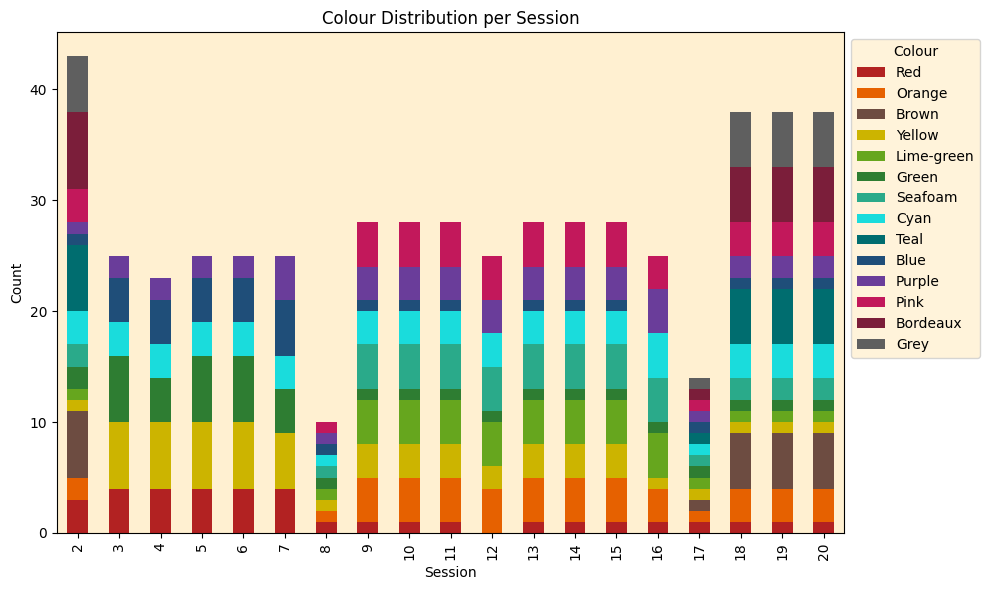

In [ ]:
# Filter data
df = sortedmaster[
    (sortedmaster["participant"] == 2)
]

# Count colors per session
counts = df.pivot_table(
    index="continuous_session",
    columns="corrColor",
    aggfunc="size",
    fill_value=0
)

# Reorder columns
counts = counts.reindex(columns=color_order, fill_value=0)

counts = counts.sort_index()
with sns.axes_style(new_style):
    ax = counts.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        color=[custom_palette[c] for c in color_order]
    )

    # Remove the axes legend
    ax.legend_.remove()

    # Add a figure-level legend outside the plot
    plt.legend(
        handles=ax.get_legend_handles_labels()[0],
        labels=ax.get_legend_handles_labels()[1],
        bbox_to_anchor=(1.00, 1),
        title="Colour"
    )

plt.xlabel("Session")
plt.ylabel("Count")
plt.title("Colour Distribution per Session")
plt.tight_layout()
plt.show()


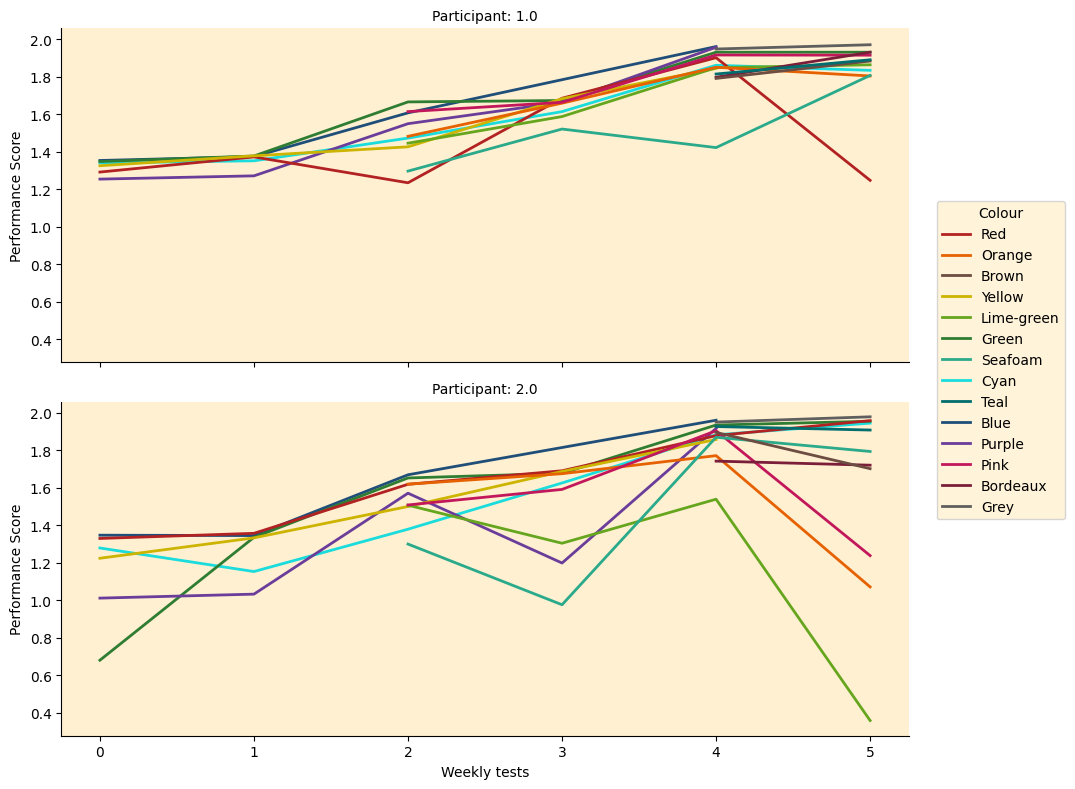

In [ ]:
with sns.axes_style(new_style):
    g = sns.relplot(
        data=color_df,
        kind="line",
        x="week",
        y="performance",
        hue="corrColor",
        row="participant",
        height=4,
        aspect=2,
        errorbar=None,
        linewidth=2,
        palette=custom_palette
    )

    # Get handles and labels from the underlying axes
    handles, labels = g.axes[0][0].get_legend_handles_labels()

    # Reorder according to your custom list
    order = [labels.index(c) for c in color_order if c in labels]

    # Remove seaborn's legend
    g._legend.remove()

    # Add new ordered legend
    g.fig.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Colour",
        bbox_to_anchor=(1.16, 0.75)
    )

    g.set_axis_labels("Weekly tests", "Performance Score")
    g.set_titles("Participant: {row_name}")
    g._legend.set_title("Colour")

    plt.tight_layout()
    plt.show()



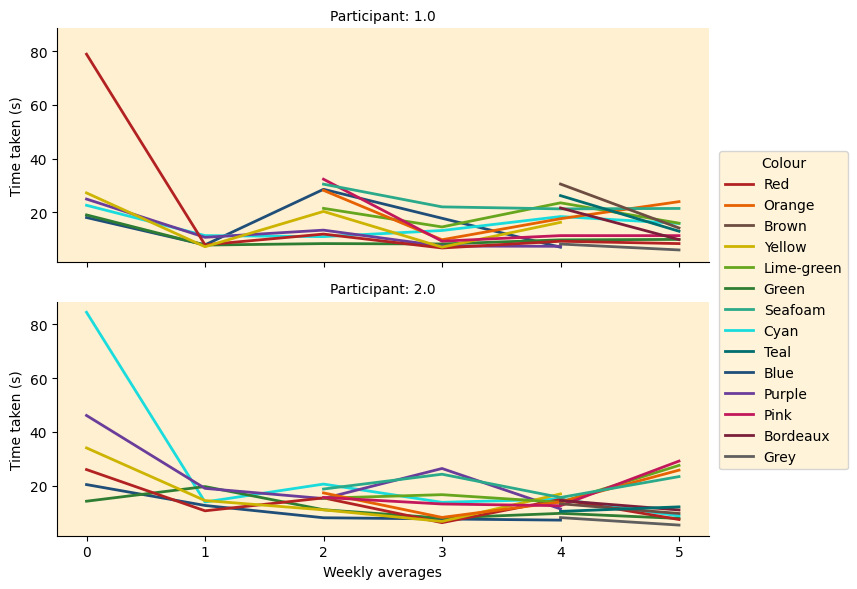

In [ ]:
with sns.axes_style(new_style):
    g = sns.relplot(
        data=color_df,
        kind="line",
        x="week",
        y="mean_time",
        hue="corrColor",
        row="participant",
        height=3,
        aspect=2,
        errorbar=None,
        linewidth=2,
        palette=custom_palette
    )

    # Get handles and labels from the underlying axes
    handles, labels = g.axes[0][0].get_legend_handles_labels()

    # Reorder according to your custom list
    order = [labels.index(c) for c in color_order if c in labels]

    # Remove seaborn's legend
    g._legend.remove()

    # Add new ordered legend
    g.fig.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Colour",
        bbox_to_anchor=(1.18, 0.75)
    )


    g.set_axis_labels("Weekly averages", "Time taken (s)")
    g.set_titles("Participant: {row_name}")
    g._legend.set_title("Colour")

    plt.tight_layout()
    plt.show()

# Logistic Regression Model

In [72]:
sortedmaster["correct_bin"] = (
    sortedmaster["corrColor"] == sortedmaster["answer.routineEndVal"]
).astype(int)

In [73]:
remove_week4 = ["Teal", "Bordeaux", "Grey", "Brown"]
remove_week2 = ["Seafoam", "Pink", "Orange", "Lime-green"]

filtered_df = sortedmaster.copy()

filtered_df = filtered_df[
    ~(
        ((filtered_df["corrColor"].isin(remove_week4)) & (filtered_df["week"] < 4)) |
        ((filtered_df["corrColor"].isin(remove_week2)) & (filtered_df["week"] < 2))
    )
]

In [74]:
filtered_df["week_col"] = np.where(
    filtered_df["corrColor"].isin(remove_week4), 
    1,
    np.where(
        filtered_df["corrColor"].isin(remove_week2),
        filtered_df["week"] - 1,
        filtered_df["week"]
    )
)

In [75]:
filtered_df

,index,image,logical,corrColor,corrR,corrG,corrB,image_path,oldColor,thisN,...,difficulty_weight,score,base_score,trial_continuous,rgb_distance,ratio_cat1,ratio_cat2,session_continuous,correct_bin,week_col
0,1,DemoRed.jpg,True,Red,96.0,6.0,0.0,Demo/DemoRed_0.png,NaN,0.0,...,1.0,1.200894,1.2,1,10.0,100,0,1,1,0.0
1,2,DemoBlue.jpg,True,Blue,0.0,0.0,90.0,Demo/DemoBlue_0.png,NaN,1.0,...,1.0,1.333366,1.2,2,10.0,100,0,1,1,0.0
2,3,DemoGreen.jpg,True,Green,0.0,98.0,5.0,Demo/DemoGreen_0.png,NaN,2.0,...,1.0,1.331295,1.2,3,7.0,100,0,1,1,0.0
3,4,DemoCyan.jpg,True,Cyan,1.0,100.0,92.0,Demo/DemoCyan_0.png,NaN,3.0,...,1.0,1.319908,1.2,4,9.0,100,100,1,1,0.0
4,5,DemoYellow.jpg,True,Yellow,96.0,100.0,0.0,Demo/DemoYellow_0.png,NaN,4.0,...,1.0,1.292313,1.2,5,4.0,100,100,1,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,33,013_Grey.jpg,True,Grey,47.0,53.0,50.0,03-1/013_Grey_0.png,NaN,32.0,...,1.4,1.981615,1.2,518,6.0,100,100,20,1,1.0
1086,34,016_Cyan.jpg,False,Cyan,0.0,97.0,100.0,03-2/016_Cyan_0.png,Blue,33.0,...,1.4,1.936761,1.2,519,3.0,100,100,20,1,4.0
1087,35,006_Brown.jpg,True,Brown,53.0,20.0,0.0,03-1/006_Brown_0.png,NaN,34.0,...,1.4,1.937512,1.2,520,13.0,50,30,20,1,1.0
1088,36,016_Bordeaux.jpg,False,Bordeaux,52.0,0.0,29.0,03-2/016_Bordeaux_0.png,Brown,35.0,...,1.4,1.959625,1.2,521,11.0,50,20,20,1,1.0


In [ ]:
logit_model = smf.logit(
    formula=(
        "correct_bin ~ C(num_colours) "
        "+ C(sessionType) "
        "+ confidence_score "
        "+ trial_time "
        "+ trial_continuous "
        "+ filterCounter "
        "+ participant "
        "+ rgb_distance "
        "+ week_col"
    ),
    data=filtered_df
).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.166591
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            correct_bin   No. Observations:                 1014
Model:                          Logit   Df Residuals:                     1003
Method:                           MLE   Df Model:                           10
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.2302
Time:                        13:52:38   Log-Likelihood:                -168.92
converged:                       True   LL-Null:                       -219.45
Covariance Type:            nonrobust   LLR p-value:                 3.361e-17
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  1.3499      1.322      1.021      0.307      -1.242      

In [ ]:
y_true = sortedmaster.correct_bin
y_pred_prob = logit_model.predict(sortedmaster)
y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)


In [ ]:
print(f"Accuracy:          {accuracy:.3f}")
print(f"Precision:         {precision:.3f}")
print(f"Recall:            {recall:.3f}")
print(f"F1 Score:          {f1:.3f}")
print("\nConfusion Matrix:")
print(cm)


Accuracy:          0.890
Precision:         0.951
Recall:            0.931
F1 Score:          0.941

Confusion Matrix:
[[ 17  49]
 [ 71 953]]


In [ ]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_df

,Predicted 0,Predicted 1
Actual 0,17,49
Actual 1,71,953


In [ ]:
sortedmaster.columns

Index(['index', 'image', 'logical', 'corrColor', 'corrR', 'corrG', 'corrB',
       'image_path', 'oldColor', 'thisN', 'slider.response', 'slider.history',
       'trials.thisIndex', 'filterCount.routineEndVal',
       'trial_counter.routineEndVal', 'trial_1.started', 'trial_1.stopped',
       'filterChange.routineEndVal', 'answer.routineEndVal',
       'confidence.started', 'confidence.stopped', 'trials.mouse_2.x',
       'trials.mouse_2.y', 'trials.mouse_2.time', 'confirm.started',
       'wrongAnswer.started', 'correctAnswer.started', 'confirm.stopped',
       'congrats.started', 'colorList.expEndVal', 'participant', 'session',
       'date', 'expName', 'frameRate', 'expStart', 'total_time', 'trial_time',
       'confidence_time', 'confirm_time', 'points', 'filterCounter',
       'sessionType', 'colorDifficulty', 'week', 'num_colours', 'accuracy',
       'confidence_score', 'mu', 'sigma', 'z_time', 'speed_score',
       'accuracy_score', 'difficulty_weight', 'score', 'base_score',
  

## Linear Regression Model
### No interactions

In [ ]:
gammamodel01 = smf.glm(
    formula=(
        "trial_time ~ C(corrColor) "
        "+ C(sessionType) "
        "+ confidence_score "
        "+ week "
        "+ rgb_distance "
    ),
    data=filtered_df,
    family=sm.families.Gamma(link=sm.families.links.log())

).fit()

print(gammamodel01.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             trial_time   No. Observations:                 1014
Model:                            GLM   Df Residuals:                      996
Model Family:                   Gamma   Df Model:                           17
Link Function:                    log   Scale:                         0.57847
Method:                          IRLS   Log-Likelihood:                -3482.5
Date:                Sun, 10 May 2026   Deviance:                       318.75
Time:                        13:52:38   Pearson chi2:                     576.
No. Iterations:                    19   Pseudo R-squ. (CS):             0.1948
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

c:\Users\emilie\AppData\Roaming\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [ ]:
with sns.axes_style(new_style):
    # Build prediction grid
    colours = filtered_df["corrColor"].unique()
    median_week = filtered_df["week"].median()

    pred_df = pd.DataFrame({
        "corrColor": colours,
        "sessionType": 3,
        "confidence_score": 0,
        "week": median_week,
        "rgb_distance": 0
    })

    # Predictions
    pred_df["pred"] = gammamodel01.predict(pred_df)

    # Confidence intervals
    ci = gammamodel01.get_prediction(pred_df).conf_int()
    pred_df["lower"] = np.exp(ci[:, 0])
    pred_df["upper"] = np.exp(ci[:, 1])

    # Sort
    pred_df = pred_df.sort_values("pred", ascending=False).reset_index(drop=True)

    # Plot
    plt.figure(figsize=(10, 8))

    y = np.arange(len(pred_df))

    plt.hlines(y, pred_df["lower"], pred_df["upper"], color="gray", linewidth=2)
    plt.scatter(pred_df["pred"], y, color="black", s=60)

    plt.yticks(y, pred_df["corrColor"])
    plt.xlabel("Predicted Trial Time (ms)")
    plt.title("Predicted Trial Time per Colour (Dot–Whisker Plot)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

NameError: name 'gammamodel01' is not defined

### Gamma mult

In [ ]:
gammamodel2mult = smf.glm(
    formula=(
        "trial_time ~ confidence_score * week * rgb_distance * C(sessionType) * C(participant)"
        " + C(corrColor) "
    ),
    data=filtered_df,
    family=sm.families.Gamma(sm.families.links.log())
).fit()
print(gammamodel2mult.summary())

c:\Users\emilie\AppData\Roaming\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:             trial_time   No. Observations:                 1014
Model:                            GLM   Df Residuals:                      956
Model Family:                   Gamma   Df Model:                           57
Link Function:                    log   Scale:                         0.52132
Method:                          IRLS   Log-Likelihood:                -3416.9
Date:                Sun, 10 May 2026   Deviance:                       278.79
Time:                        13:52:38   Pearson chi2:                     498.
No. Iterations:                    24   Pseudo R-squ. (CS):             0.2709
Covariance Type:            nonrobust                                         
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

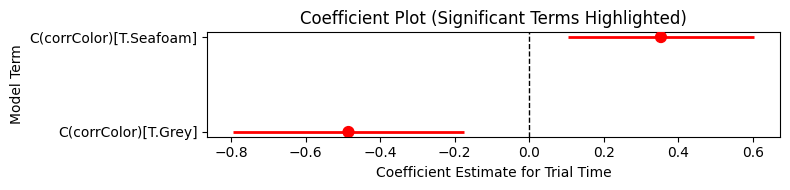

In [ ]:
# Extract coefficients and confidence intervals
coef = gammamodel2mult.params
conf = gammamodel2mult.conf_int()
conf.columns = ["lower", "upper"]

# Combine into one dataframe
coef_df = pd.concat([coef, conf], axis=1)
coef_df = coef_df.rename(columns={0: "coef"})

# Remove intercept
coef_df = coef_df.drop("Intercept")

# Add significance flag
coef_df["significant"] = ((coef_df["lower"] > 0) | (coef_df["upper"] < 0))

filtered = coef_df[coef_df["significant"]].copy()

# Sort by magnitude
filtered = filtered.reindex(filtered["coef"].abs().sort_values(ascending=False).index)

# Build arrays
y_positions = np.arange(len(filtered))
coef_vals = filtered["coef"].values
lower = filtered["lower"].values
upper = filtered["upper"].values

# Colors
colors = np.where(filtered["significant"], "red", "lightgray")

# Plot
plt.figure(figsize=(8, 2))

# Horizontal CI lines
plt.hlines(
    y=y_positions,
    xmin=lower,
    xmax=upper,
    color=colors,
    linewidth=2
)

# Points
plt.scatter(
    coef_vals,
    y_positions,
    c=colors,
    s=60,
    zorder=3
)

# Zero line
plt.axvline(0, color="black", linestyle="--", linewidth=1)

# Labels
plt.yticks(y_positions, filtered.index)

ax = plt.gca()
for tick_label, sig in zip(ax.get_yticklabels(), filtered["significant"]):
    tick_label.set_color("black" if sig else "lightgray")

plt.title("Coefficient Plot (Significant Terms Highlighted)")
plt.xlabel("Coefficient Estimate for Trial Time")
plt.ylabel("Model Term")
plt.tight_layout()
plt.show()

## Colour x Participant

In [ ]:
gammamodel2 = smf.glm(
    formula=(
        "trial_time ~ C(corrColor) * C(participant)"
        "+ C(sessionType) "
        "+ confidence_score "
        "+ week"
        "+ rgb_distance "
    ),
    data=filtered_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(gammamodel2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             trial_time   No. Observations:                 1014
Model:                            GLM   Df Residuals:                      983
Model Family:                   Gamma   Df Model:                           30
Link Function:                    log   Scale:                         0.54327
Method:                          IRLS   Log-Likelihood:                -3446.0
Date:                Sun, 10 May 2026   Deviance:                       297.42
Time:                        13:52:38   Pearson chi2:                     534.
No. Iterations:                    21   Pseudo R-squ. (CS):             0.2362
Covariance Type:            nonrobust                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

c:\Users\emilie\AppData\Roaming\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


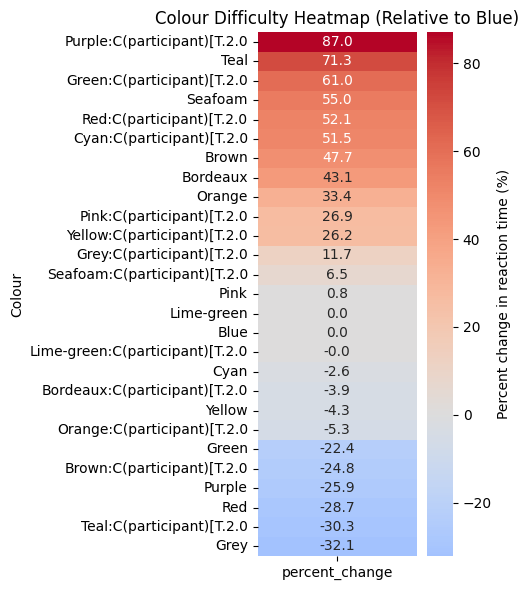

In [ ]:
# Extract only the colour rows from the GLM
colour_effects = glm_model.params.filter(like="C(corrColor)")

# Convert log-coefficients → multiplicative effect → percent change
colour_df = pd.DataFrame({
    "colour": colour_effects.index.str.replace("C(corrColor)[T.", "").str.replace("]", ""),
    "log_coef": colour_effects.values
})
colour_df["multiplier"] = np.exp(colour_df["log_coef"])
colour_df["percent_change"] = (colour_df["multiplier"] - 1) * 100
plt.figure(figsize=(5, 6))

# Sort by difficulty (slowest at top)
colour_df_sorted = colour_df.sort_values("percent_change", ascending=False)
# Add baseline colour (Blue)
baseline_row = pd.DataFrame({
    "colour": ["Blue"],
    "log_coef": [0],
    "multiplier": [1],
    "percent_change": [0]
})

# Append to your existing dataframe
colour_df_with_baseline = pd.concat([colour_df, baseline_row], ignore_index=True)

# Sort for plotting
colour_df_sorted = colour_df_with_baseline.sort_values("percent_change", ascending=False)

sns.heatmap(
    colour_df_sorted[["percent_change"]].set_index(colour_df_sorted["colour"]),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".1f",
    cbar_kws={"label": "Percent change in reaction time (%)"}
)

plt.title("Colour Difficulty Heatmap (Relative to Blue)")
plt.xlabel("")
plt.ylabel("Colour")
plt.tight_layout()
plt.show()


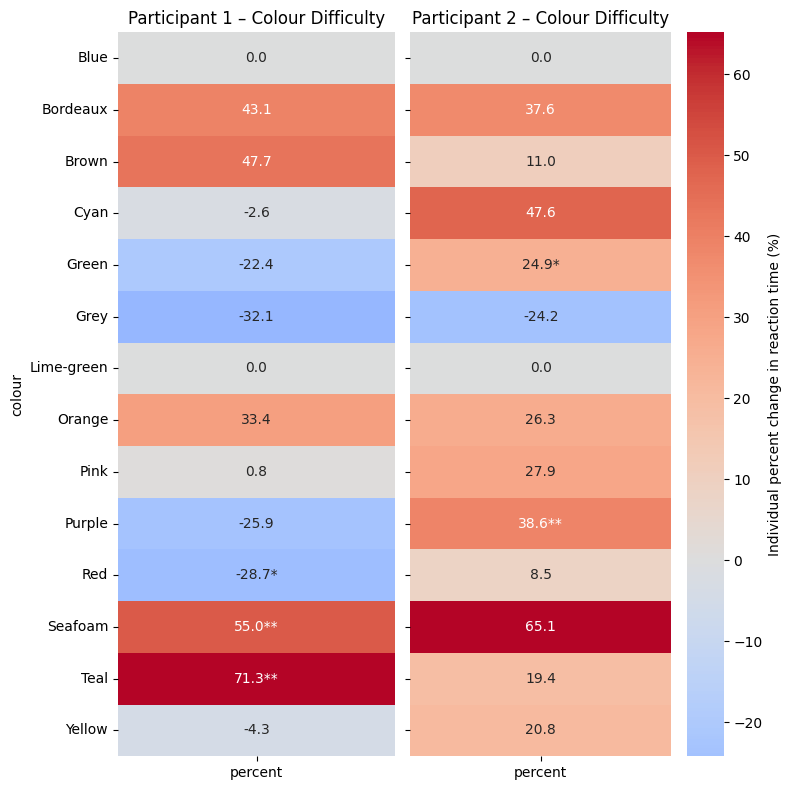

In [ ]:
params = glm_model.params
pvals = glm_model.pvalues

# Get all colours alphabetically, but Blue must be first
all_colours = sorted(sortedmaster["corrColor"].unique().tolist())
all_colours = ["Blue"] + [c for c in all_colours if c != "Blue"]


def get_log_effect(colour, participant):
    """Return log-effect for a given colour and participant,
       using Blue as baseline for each participant."""
    
    # Blue is baseline for BOTH participants
    if colour == "Blue":
        return 0.0

    # Main colour effect
    main_term = f"C(corrColor)[T.{colour}]"
    log_main = params.get(main_term, 0.0)

    # Interaction term (participant-specific adjustment)
    inter_term = f"{main_term}:C(participant)[T.{participant}.0]"
    log_inter = params.get(inter_term, 0.0)

    # Participant 1: no interaction
    if participant == 1:
        return log_main

    # Participant 2: add interaction only
    return log_main + log_inter


def get_p_value(colour, participant):
    if colour == "Blue":
        return 1.0  # baseline has no p-value

    main_term = f"C(corrColor)[T.{colour}]"
    inter_term = f"{main_term}:C(participant)[T.{participant}.0]"

    if participant == 1:
        return pvals.get(main_term, 1.0)
    else:
        return pvals.get(inter_term, 1.0)


def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""


def build_participant_df(participant):
    """Build dataframe for one participant."""
    rows = []

    for colour in all_colours:
        log_eff = get_log_effect(colour, participant)
        pval = get_p_value(colour, participant)
        percent = (np.exp(log_eff) - 1) * 100

        rows.append({
            "colour": colour,
            "percent": percent,
            "stars": stars(pval),
            "annot": f"{percent:.1f}{stars(pval)}"
        })

    df = pd.DataFrame(rows)
    df = df.set_index("colour")
    return df


# Build both participant dataframes
df_p1 = build_participant_df(1)
df_p2 = build_participant_df(2)


fig, axes = plt.subplots(1, 2, figsize=(8, 8), sharey=True, gridspec_kw={"width_ratios": [0.85, 1]})

sns.heatmap(
    df_p1[["percent"]],
    annot=df_p1[["annot"]], fmt="",
    cmap="coolwarm", center=0, ax=axes[0], cbar=False
)
axes[0].set_title("Participant 1 – Colour Difficulty")
axes[0].set_xlabel("")

sns.heatmap(
    df_p2[["percent"]],
    annot=df_p2[["annot"]], fmt="",
    cmap="coolwarm", center=0, ax=axes[1],
    cbar_kws={"label": "Individual percent change in reaction time (%)"}
)
axes[1].set_title("Participant 2 – Colour Difficulty")
axes[1].set_ylabel("")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


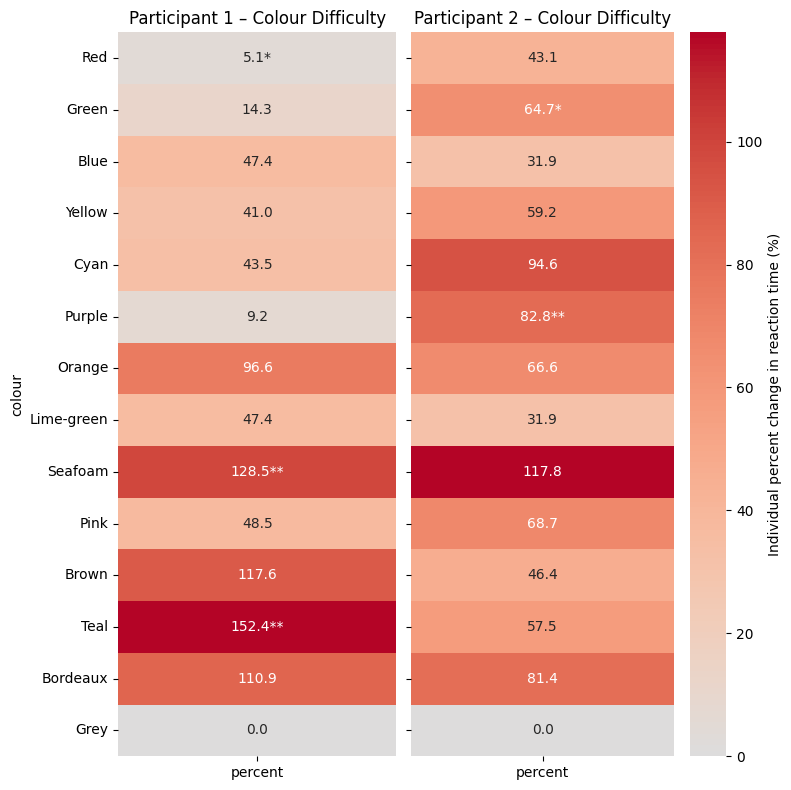

In [ ]:
def get_log_effect(colour, participant):
    """Return log-effect for a given colour and participant,
       using Grey as the baseline for BOTH participants."""

    # Get Grey main effect
    grey_main = params.get("C(corrColor)[T.Grey]", 0.0)

    # Get Grey interaction effect (participant-specific)
    grey_inter = params.get("C(corrColor)[T.Grey]:C(participant)[T.%d.0]" % participant, 0.0)

    # Grey is the new baseline
    if colour == "Grey":
        return 0.0

    # Main colour effect
    main_term = f"C(corrColor)[T.{colour}]"
    log_main = params.get(main_term, 0.0)

    # Interaction term
    inter_term = f"{main_term}:C(participant)[T.{participant}.0]"
    log_inter = params.get(inter_term, 0.0)

    # Participant-specific effect relative to Grey
    return (log_main + log_inter) - (grey_main + grey_inter)

custom_order = [
    "Red", "Green", "Blue", "Yellow", "Cyan", "Purple",
    "Orange", "Lime-green", "Seafoam", "Pink", "Brown",
    "Teal", "Bordeaux", "Grey"
]

# Build both participant dataframes
df_p1 = build_participant_df(1)
df_p2 = build_participant_df(2)

df_p1 = df_p1.reindex(custom_order)
df_p2 = df_p2.reindex(custom_order)

fig, axes = plt.subplots(1, 2, figsize=(8, 8), sharey=True, gridspec_kw={"width_ratios": [0.85, 1]})

sns.heatmap(
    df_p1[["percent"]],
    annot=df_p1[["annot"]], fmt="",
    cmap="coolwarm", center=0, ax=axes[0], cbar=False
)
axes[0].set_title("Participant 1 – Colour Difficulty")
axes[0].set_xlabel("")

sns.heatmap(
    df_p2[["percent"]],
    annot=df_p2[["annot"]], fmt="",
    cmap="coolwarm", center=0, ax=axes[1],
    cbar_kws={"label": "Individual percent change in reaction time (%)"}
)
axes[1].set_title("Participant 2 – Colour Difficulty")
axes[1].set_ylabel("")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


In [ ]:
df_p2

,percent,stars,annot
colour,,,
Red,43.097387,,43.1
Green,64.663561,*,64.7*
Blue,31.874630,,31.9
Yellow,59.243729,,59.2
Cyan,94.589851,,94.6
Purple,82.833002,**,82.8**
Orange,66.620709,,66.6
Lime-green,31.874630,,31.9
Seafoam,117.783305,,117.8


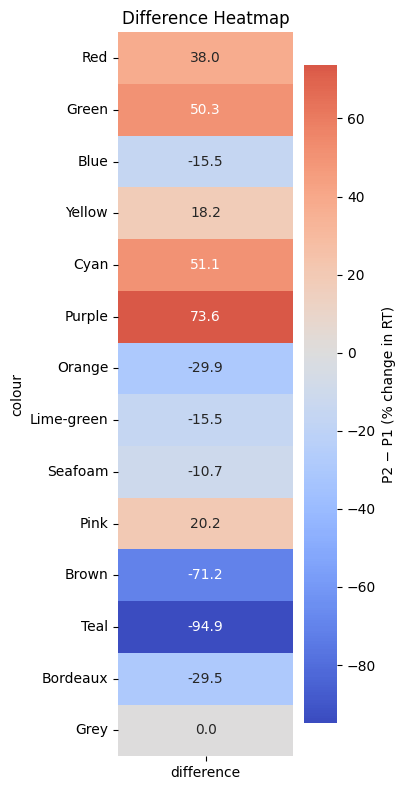

In [ ]:
df_diff = pd.DataFrame({
    "colour": custom_order,
    "difference": df_p2["percent"] - df_p1["percent"]
}).set_index("colour")

plt.figure(figsize=(4, 8))
sns.heatmap(
    df_diff[["difference"]],
    annot=True, fmt=".1f", cmap="coolwarm", center=0,
    cbar_kws={"label": "P2 − P1 (% change in RT)"}
)
plt.title("Difference Heatmap")
plt.tight_layout()
plt.show()
    

### Individual difficulty scoring

In [ ]:
df_p1_master = sortedmaster[sortedmaster["participant"] == 1].copy()
df_p2_master = sortedmaster[sortedmaster["participant"] == 2].copy()

df_p1_master["individual_col_dif"] = df_p1_master["corrColor"].map(df_p1["percent"])* 0.01
df_p2_master["individual_col_dif"] = df_p2_master["corrColor"].map(df_p2["percent"])* 0.01

df_p1_master["performance_factor"] = df_p1_master["accuracy"].apply(lambda x: 1 if x == 1 else -1)
df_p2_master["performance_factor"] = df_p2_master["accuracy"].apply(lambda x: 1 if x == 1 else -1)

df_p1_master["difficulty_bonus"] = df_p1_master["individual_col_dif"] * df_p1_master["performance_factor"]
df_p2_master["difficulty_bonus"] = df_p2_master["individual_col_dif"] * df_p2_master["performance_factor"]

df_p1_master["combined_score"] = (
    df_p1_master["base_score"]
    + df_p1_master["speed_score"] * 0.5
    + df_p1_master["difficulty_bonus"]
)

df_p2_master["combined_score"] = (
    df_p2_master["base_score"]
    + df_p2_master["speed_score"] * 0.5
    + df_p2_master["difficulty_bonus"]
)


display(df_p2_master)
combined_master = pd.concat([df_p1_master, df_p2_master], ignore_index=True)


,index,image,logical,corrColor,corrR,corrG,corrB,image_path,oldColor,thisN,...,difficulty_weight,score,base_score,trial_continuous,rgb_distance,correct_bin,individual_col_dif,performance_factor,difficulty_bonus,combined_score
568,1,DemoRed.jpg,True,Red,96.0,6.0,0.0,Demo/DemoRed_0.png,NaN,0.0,...,1.00,1.297149,1.2,1,10.0,1,0.430974,1,0.430974,1.792890
569,2,DemoBlue.jpg,True,Blue,0.0,0.0,90.0,Demo/DemoBlue_0.png,NaN,1.0,...,1.00,1.330230,1.2,2,10.0,1,0.318746,1,0.318746,1.735797
570,3,DemoGreen.jpg,True,Green,0.0,98.0,5.0,Demo/DemoGreen_0.png,NaN,2.0,...,1.00,0.165104,0.0,3,7.0,0,0.646636,-1,-0.646636,-0.371462
571,4,DemoCyan.jpg,True,Cyan,1.0,100.0,92.0,Demo/DemoCyan_0.png,NaN,3.0,...,1.00,1.200667,1.2,4,9.0,1,0.945899,1,0.945899,2.147011
572,5,DemoYellow.jpg,True,Yellow,96.0,100.0,0.0,Demo/DemoYellow_0.png,NaN,4.0,...,1.00,1.282522,1.2,5,4.0,1,0.592437,1,0.592437,1.929975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,33,013_Grey.jpg,True,Grey,47.0,53.0,50.0,03-1/013_Grey_0.png,NaN,32.0,...,1.45,2.052387,1.2,518,6.0,1,0.000000,1,0.000000,1.559065
1086,34,016_Cyan.jpg,False,Cyan,0.0,97.0,100.0,03-2/016_Cyan_0.png,Blue,33.0,...,1.45,2.005931,1.2,519,3.0,1,0.945899,1,0.945899,2.451566
1087,35,006_Brown.jpg,True,Brown,53.0,20.0,0.0,03-1/006_Brown_0.png,NaN,34.0,...,1.45,2.006708,1.2,520,13.0,1,0.464093,1,0.464093,1.970655
1088,36,016_Bordeaux.jpg,False,Bordeaux,52.0,0.0,29.0,03-2/016_Bordeaux_0.png,Brown,35.0,...,1.45,2.029611,1.2,521,11.0,1,0.814289,1,0.814289,2.347175


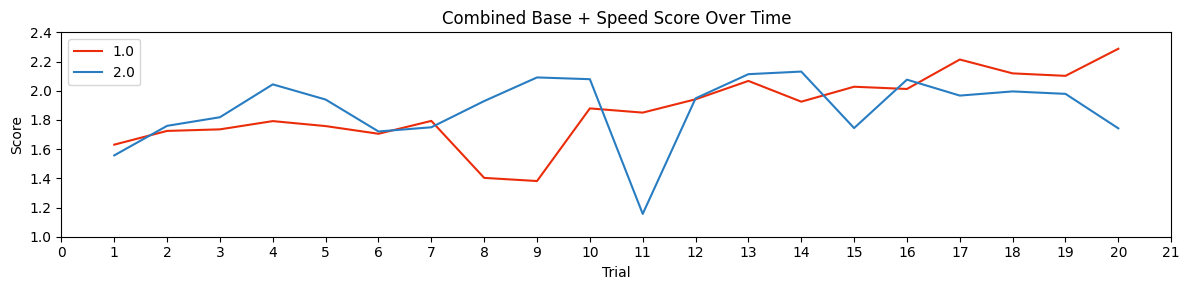

In [ ]:


session_df = (
    combined_master.groupby(["participant", "week", "session"])
    .agg(
        mean_score=("combined_score", "mean"),
        mean_basescore=("base_score", "mean"),
        accuracy_rate=("accuracy", "mean"),
        mean_time=("speed_score", "mean"),
        mean_confidence=("slider.response", "mean"),
        mean_difficulty=("individual_col_dif", "mean"),
        n_trials=("score", "size")
    )
    .reset_index()
)

session_df = session_df.sort_values(["participant", "week", "session"])

session_df["session_order"] = (
    session_df.groupby("participant").cumcount() + 1
)
session_df["speed"] = 1 / session_df["mean_time"]

custom_palette1 = sns.color_palette(["#EB2C0A", "#287DC2"])

plt.figure(figsize=(12, 3))

ax = sns.lineplot(data=session_df, x="session_order", y="performance", hue="participant", errorbar=None, palette=custom_palette1)
ax.set(xlim=(0,17),ylim=(1,2.4))
ax.set_xticks(range(0,22,1))
ax.grid(False)
plt.title("Combined Base + Speed Score Over Time")
plt.xlabel("Trial")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


## Colour x Week

In [ ]:
gammamodel3 = smf.glm(
    formula="trial_time ~ C(week)*C(corrColor)",
    data=filtered_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
print(gammamodel3.summary())

c:\Users\emilie\AppData\Roaming\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:             trial_time   No. Observations:                 1090
Model:                            GLM   Df Residuals:                     1045
Model Family:                   Gamma   Df Model:                           44
Link Function:                    log   Scale:                         0.70020
Method:                          IRLS   Log-Likelihood:                -3857.7
Date:                Sun, 10 May 2026   Deviance:                       384.73
Time:                        13:52:40   Pearson chi2:                     729.
No. Iterations:                   100   Pseudo R-squ. (CS):             0.1013
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

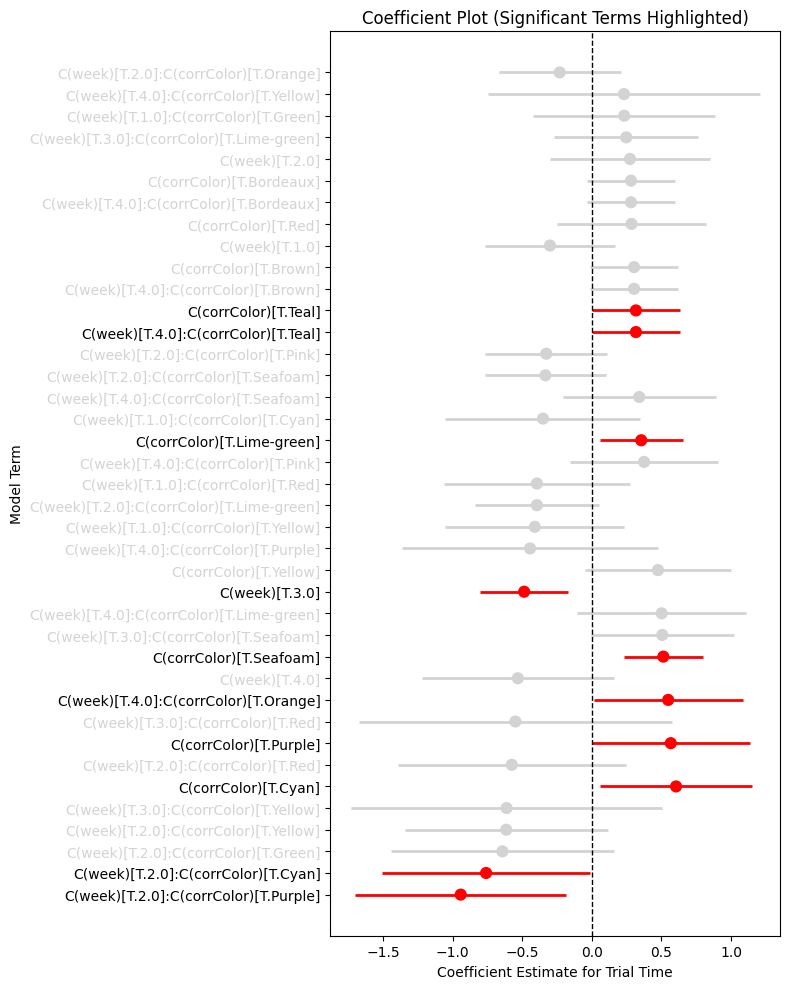

In [459]:
# Extract coefficients and confidence intervals
coef = gammamodel3.params
conf = gammamodel3.conf_int()
conf.columns = ["lower", "upper"]

# Combine into one dataframe
coef_df = pd.concat([coef, conf], axis=1)
coef_df = coef_df.rename(columns={0: "coef"})

# Remove intercept
coef_df = coef_df.drop("Intercept")

# Add significance flag
coef_df["significant"] = ((coef_df["lower"] > 0) | (coef_df["upper"] < 0))

# Filter to important terms
filtered = coef_df[
    (coef_df["significant"]) | (coef_df["coef"].abs() > 0.2)
].copy()

# Sort by magnitude
filtered = filtered.reindex(filtered["coef"].abs().sort_values(ascending=False).index)

# Build arrays
y_positions = np.arange(len(filtered))
coef_vals = filtered["coef"].values
lower = filtered["lower"].values
upper = filtered["upper"].values

# Colors
colors = np.where(filtered["significant"], "red", "lightgray")

# Plot
plt.figure(figsize=(8, 10))

# Horizontal CI lines
plt.hlines(
    y=y_positions,
    xmin=lower,
    xmax=upper,
    color=colors,
    linewidth=2
)

# Points
plt.scatter(
    coef_vals,
    y_positions,
    c=colors,
    s=60,
    zorder=3
)

# Zero line
plt.axvline(0, color="black", linestyle="--", linewidth=1)

# Labels
plt.yticks(y_positions, filtered.index)

ax = plt.gca()
for tick_label, sig in zip(ax.get_yticklabels(), filtered["significant"]):
    tick_label.set_color("black" if sig else "lightgray")

plt.title("Coefficient Plot (Significant Terms Highlighted)")
plt.xlabel("Coefficient Estimate for Trial Time")
plt.ylabel("Model Term")
plt.tight_layout()
plt.show()

In [345]:
lin_model = smf.glm(
    formula="trial_time ~ C(week)*C(corrColor) + sessionType + rgb_distance",
    data=sortedmaster,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
print(lin_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             trial_time   No. Observations:                 1014
Model:                            GLM   Df Residuals:                      970
Model Family:                   Gamma   Df Model:                           43
Link Function:                    log   Scale:                         0.62333
Method:                          IRLS   Log-Likelihood:                -3526.7
Date:                Sun, 24 May 2026   Deviance:                       346.84
Time:                        19:35:01   Pearson chi2:                     605.
No. Iterations:                    26   Pseudo R-squ. (CS):             0.1450
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

c:\Users\emilie\AppData\Roaming\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


## Colour x RGB_distance

In [461]:
lin_model = smf.glm(
    formula="trial_time ~ rgb_distance * C(corrColor) ",
    data=filtered_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
print(lin_model.summary())

c:\Users\emilie\AppData\Roaming\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:             trial_time   No. Observations:                 1014
Model:                            GLM   Df Residuals:                      988
Model Family:                   Gamma   Df Model:                           25
Link Function:                    log   Scale:                         0.75865
Method:                          IRLS   Log-Likelihood:                -3612.5
Date:                Sun, 10 May 2026   Deviance:                       384.55
Time:                        13:52:40   Pearson chi2:                     750.
No. Iterations:                    31   Pseudo R-squ. (CS):            0.07659
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------